# Allman latent-class MNAR simulation

## tl;dr

In 100 replications with $n=500$, the complete-data oracle has $M_j$ RMSE 0.0373 and $p_f$ RMSE 0.0351. The proposed estimated-bridge method remains close at 0.0466 and 0.0452, whereas MAR deteriorates to 0.0724 and 0.0929. Thus the single Allman-type Bernoulli-product model yields the intended benchmark comparison without introducing additional outcome families. All numerical probabilities are study-specific calibration values because Allman, Matias and Rhodes (2009) report identification results, not Monte Carlo bias tables.

## Model

Allman, Matias and Rhodes (2009, Section 3) define the $r$-class, $p$-feature model $M(r;\kappa_1,\ldots,\kappa_p)$. Their conditional-independence statement is: “conditional on $Z$, the $X_j$'s are independent random variables.” In their notation,

$$
P_i=\bigotimes_{j=1}^p p_{ij},\qquad
P=\sum_{i=1}^r \pi_iP_i.
$$

We use exactly this model class with $r=2$, $p=4$, and binary observed features $(W,Y_1,Y_2,Y_3)$. The latent class is denoted by $F$ in our paper. Since $p=4$ and $r=2$, the Bernoulli-product model satisfies the generic-identification bound in Allman et al. (2009, Corollary 5).

### What can and cannot be reproduced

The model definition and identification condition above come directly from Allman et al. The paper does not specify a numerical DGP, sample size, optimizer, bias, RMSE, standard error, or coverage result. Therefore the complete-data oracle below is our reproducibility benchmark; there is no Allman Monte Carlo table to match.

## Setup

- `full_data_oracle`: fit the Allman model before missingness.
- `mar`: fit the same latent model to observed supported pairs without MNAR correction.
- `proposed_bridge`: estimate each block propensity from the conditional bridge moments and fit the bridge-weighted pairwise latent model.

The two primary targets are the three class-specific measurement kernels $M_j$ and the latent class proportion $p_f=P(F=f)$.

In [1]:
from pathlib import Path
import sys
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "simulation":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from simulation.latent_mnar_sim import load_config, run_simulation

CONFIG_PATH = ROOT / "simulation" / "config.yml"
config = load_config(CONFIG_PATH)
print(config["model"]["name"])
print(f"n={config['sample_size']}, replications={config['pilot_replications']}")

M(r; kappa_1, ..., kappa_p)
n=500, replications=100


## Simulation

In [2]:
summary, overlap, bridge_diagnostics = run_simulation(config)
results_dir = ROOT / "simulation" / "results"
results_dir.mkdir(exist_ok=True)
summary.to_csv(results_dir / "allman_summary.csv", index=False)
overlap.to_csv(results_dir / "allman_overlap.csv", index=False)
bridge_diagnostics.to_csv(results_dir / "allman_bridge_diagnostics.csv", index=False)
summary.round(4)

,method,M_bias,M_mean_absolute_error,p_f1_bias,mean_iterations,M_RMSE,p_f1_RMSE
0,full_data_oracle,0.0036,0.0296,0.0029,40.11,0.0373,0.0351
1,mar,-0.0474,0.0551,-0.0792,52.84,0.0724,0.0929
2,proposed_bridge,-0.0027,0.0366,-0.0028,42.58,0.0466,0.0452


## Primary results

Bias and RMSE for $M_j$ and $p_f$ are the main simulation outputs.

In [3]:
summary[[
    "method", "M_bias", "M_mean_absolute_error", "M_RMSE",
    "p_f1_bias", "p_f1_RMSE"
]].round(4)

,method,M_bias,M_mean_absolute_error,M_RMSE,p_f1_bias,p_f1_RMSE
0,full_data_oracle,0.0036,0.0296,0.0373,0.0029,0.0351
1,mar,-0.0474,0.0551,0.0724,-0.0792,0.0929
2,proposed_bridge,-0.0027,0.0366,0.0466,-0.0028,0.0452


### Bias and RMSE comparison

The lines compare directional bias and RMSE across the three estimators. The two panels use separate vertical scales because measurement probabilities and class proportions are different estimands.

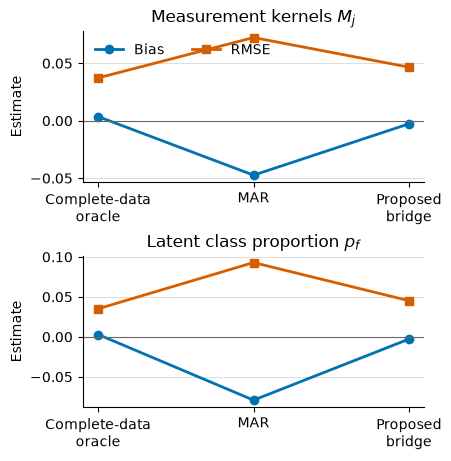

In [4]:
import matplotlib.pyplot as plt

method_order = ["full_data_oracle", "mar", "proposed_bridge"]
method_labels = ["Complete-data\noracle", "MAR", "Proposed\nbridge"]
plot_data = summary.set_index("method").loc[method_order]
x = range(len(method_order))
colors = {"Bias": "#0072B2", "RMSE": "#D55E00"}

fig, axes = plt.subplots(2, 1, figsize=(4.4, 4.5), constrained_layout=True)
for axis, bias_column, rmse_column, title in [
    (axes[0], "M_bias", "M_RMSE", r"Measurement kernels $M_j$"),
    (axes[1], "p_f1_bias", "p_f1_RMSE", r"Latent class proportion $p_f$"),
]:
    axis.plot(x, plot_data[bias_column], marker="o", linewidth=2.0,
              color=colors["Bias"], label="Bias")
    axis.plot(x, plot_data[rmse_column], marker="s", linewidth=2.0,
              color=colors["RMSE"], label="RMSE")
    axis.axhline(0, color="#666666", linewidth=0.8)
    axis.set_xticks(list(x), method_labels)
    axis.set_title(title)
    axis.set_ylabel("Estimate")
    axis.grid(axis="y", color="#DDDDDD", linewidth=0.7)
    axis.spines[["top", "right"]].set_visible(False)
axes[0].legend(frameon=False, loc="upper left", ncol=2)
figure_dir = ROOT / "simulation" / "figures"
figure_dir.mkdir(exist_ok=True)
fig.savefig(figure_dir / "allman_bias_rmse_comparison.pdf", bbox_inches="tight")
fig.savefig(figure_dir / "allman_bias_rmse_comparison.png", dpi=220, bbox_inches="tight")
plt.show()

## Supporting diagnostics

These quantities verify the design but are not intended as headline results.

In [5]:
overlap[[
    "item_observation_rate", "anchor_pair_rate", "extension_pair_rate",
    "complete_case_rate", "minimum_true_pair_propensity"
]].mean().round(4)

item_observation_rate           0.7997
anchor_pair_rate                0.7000
extension_pair_rate             0.6991
complete_case_rate              0.5089
minimum_true_pair_propensity    0.4749
dtype: float64

In [6]:
bridge_diagnostics.groupby("block").agg(
    convergence_rate=("converged", "mean"),
    mean_moment_norm=("moment_norm", "mean"),
    mean_minimum_information_eigenvalue=("minimum_information_eigenvalue", "mean"),
).round(4)

,convergence_rate,mean_moment_norm,mean_minimum_information_eigenvalue
block,,,
0,1.0,0.2423,0.0281
1,1.0,0.2455,0.0313


## Interpretation

The complete-data oracle verifies that the chosen Allman-model calibration is estimable at $n=500$. Relative to that benchmark, the proposed bridge adds moderate sampling variation but removes nearly all of the directional bias induced by MNAR selection: $M_j$ bias is -0.0027 and $p_f$ bias is -0.0028, compared with -0.0474 and -0.0792 under MAR. These are results from our calibration and are not a reproduction of an Allman simulation table, because no such table appears in that paper.